In [1]:
import os
import sys
from pathlib import Path

if os.getcwd().endswith("scripts"):
    os.chdir("..")
sys.path.insert(0, "src")

import yaml
import torch

from utils import resolve_device, set_seed, plot_history
from data import get_loaders
from models import PlainCNN, ResNet, PlainCNNDeep, ResNetDeep
from trainer import train, evaluate



In [2]:
config_path = "configs.yaml"
with open(config_path, "r") as f:   
    cfg = yaml.safe_load(f)

device = resolve_device(cfg["device"])
print(f"Device: {device}")

SEED = cfg.get("seed", 42)
set_seed(SEED)
print(f"Random seed set to: {SEED}")


Device: xpu
Random seed set to: 42


In [3]:
train_loader, val_loader, test_loader = get_loaders(
    data_dir="data",
    batch_size=cfg["data"]["batch_size"],
    num_workers=cfg["data"]["num_workers"],
    augment=cfg["train"]["augment"],
    val_split_seed=cfg["train"]["val_split_seed"]
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of testing batches: {len(test_loader)}")


Number of training batches: 704
Number of validation batches: 79
Number of testing batches: 157


In [4]:
plain_cnn_deep = PlainCNNDeep(num_classes=cfg["model"]["num_classes"]).to(device)
plain_cnn_deep_optimizer = torch.optim.Adam(plain_cnn_deep.parameters(), lr=1e-3)

resnet_deep = ResNetDeep(num_classes=cfg["model"]["num_classes"]).to(device)
resnet_deep_optimizer = torch.optim.Adam(resnet_deep.parameters(), lr=1e-3)

criterion = torch.nn.CrossEntropyLoss()

# print(plain_cnn)
print(f"Number of parameters (Plain CNN Deep): {sum(p.numel() for p in plain_cnn_deep.parameters()):,}")
# print(resnet)
print(f"Number of parameters (ResNet Deep): {sum(p.numel() for p in resnet_deep.parameters()):,}")

Number of parameters (Plain CNN Deep): 677,610
Number of parameters (ResNet Deep): 687,498


[11:21:39] Epoch 01/30
Train: [1.4547, 0.4592] | Val: [1.2942, 0.5290] | 34.76s
New best model saved at checkpoints\best_plain_cnn_deep.pt with val_acc: 0.5290

[11:22:14] Epoch 02/30
Train: [1.0436, 0.6248] | Val: [1.0193, 0.6478] | 34.16s
New best model saved at checkpoints\best_plain_cnn_deep.pt with val_acc: 0.6478

[11:22:48] Epoch 03/30
Train: [0.8651, 0.6951] | Val: [0.8453, 0.7102] | 32.71s
New best model saved at checkpoints\best_plain_cnn_deep.pt with val_acc: 0.7102

[11:23:20] Epoch 04/30
Train: [0.7391, 0.7410] | Val: [0.7940, 0.7266] | 32.70s
New best model saved at checkpoints\best_plain_cnn_deep.pt with val_acc: 0.7266

[11:23:53] Epoch 05/30
Train: [0.6569, 0.7718] | Val: [0.7306, 0.7522] | 33.76s
New best model saved at checkpoints\best_plain_cnn_deep.pt with val_acc: 0.7522

[11:24:27] Epoch 06/30
Train: [0.5988, 0.7925] | Val: [0.7348, 0.7598] | 32.75s
New best model saved at checkpoints\best_plain_cnn_deep.pt with val_acc: 0.7598

[11:25:00] Epoch 07/30
Train: [0.5

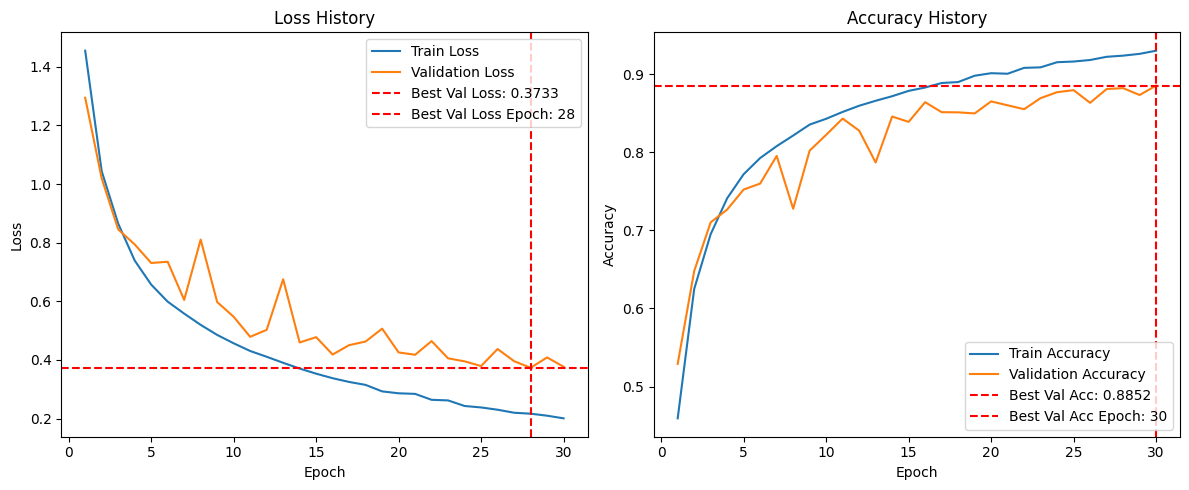

In [5]:
epochs = cfg.get("train", {}).get("epochs", 10)
ckpt_dir = cfg.get("train", {}).get("checkpoint_dir", "checkpoints")
ckpt_dir = Path(ckpt_dir)

history = train(
    model=plain_cnn_deep,
    optimizer=plain_cnn_deep_optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epochs,
    ckpt_dir=ckpt_dir,
    save_name="best_plain_cnn_deep.pt"
)

plot_history(history, save_path=ckpt_dir / "history_plain_cnn_deep.png", show=True)


In [6]:
print(f"Loading best model from {ckpt_dir / 'best_plain_cnn_deep.pt'}")
print(f"Best Val Loss: {min(history['val_loss']):.4f} | Best Val Acc: {max(history['val_acc']):.4f}")
plain_cnn_deep.load_state_dict(torch.load(ckpt_dir / "best_plain_cnn_deep.pt"))

test_loss, test_acc = evaluate(plain_cnn_deep, criterion, test_loader, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


Loading best model from checkpoints\best_plain_cnn_deep.pt
Best Val Loss: 0.3733 | Best Val Acc: 0.8852
Test Loss: 0.4197 | Test Acc: 0.8748


[11:38:39] Epoch 01/30
Train: [1.4479, 0.4671] | Val: [1.2941, 0.5432] | 22.68s
New best model saved at checkpoints\best_resnet_deep.pt with val_acc: 0.5432

[11:39:02] Epoch 02/30
Train: [1.0761, 0.6144] | Val: [0.9924, 0.6424] | 21.12s
New best model saved at checkpoints\best_resnet_deep.pt with val_acc: 0.6424

[11:39:23] Epoch 03/30
Train: [0.9047, 0.6812] | Val: [0.8716, 0.6934] | 20.92s
New best model saved at checkpoints\best_resnet_deep.pt with val_acc: 0.6934

[11:39:44] Epoch 04/30
Train: [0.7846, 0.7251] | Val: [0.8480, 0.7018] | 21.04s
New best model saved at checkpoints\best_resnet_deep.pt with val_acc: 0.7018

[11:40:05] Epoch 05/30
Train: [0.7052, 0.7538] | Val: [0.7172, 0.7472] | 21.25s
New best model saved at checkpoints\best_resnet_deep.pt with val_acc: 0.7472

[11:40:26] Epoch 06/30
Train: [0.6480, 0.7752] | Val: [0.6269, 0.7822] | 21.15s
New best model saved at checkpoints\best_resnet_deep.pt with val_acc: 0.7822

[11:40:48] Epoch 07/30
Train: [0.5987, 0.7926] | Val

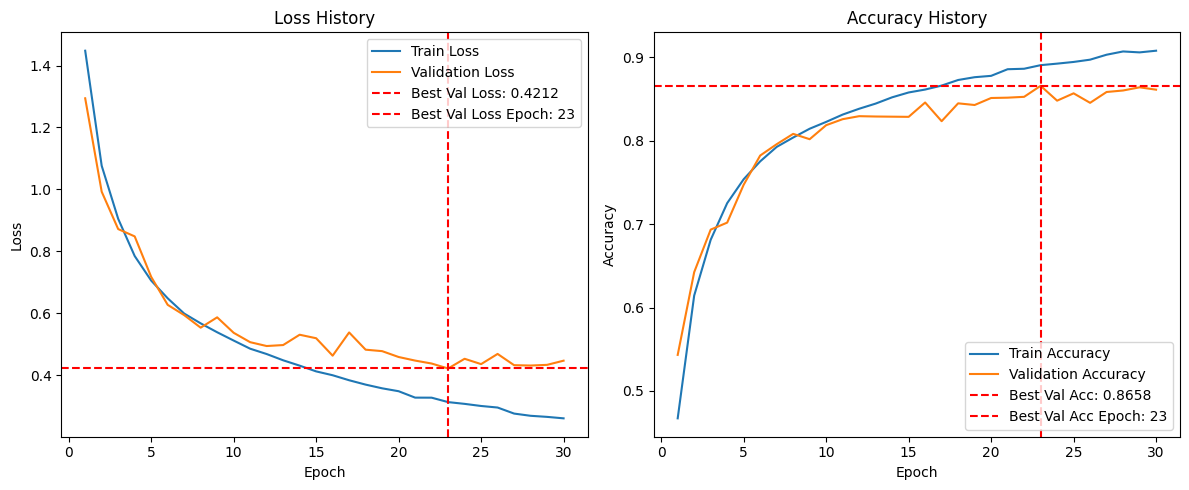

In [7]:
epochs = cfg.get("train", {}).get("epochs", 10)
ckpt_dir = cfg.get("train", {}).get("checkpoint_dir", "checkpoints")
ckpt_dir = Path(ckpt_dir)

history = train(
    model=resnet_deep,
    optimizer=resnet_deep_optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epochs,
    ckpt_dir=ckpt_dir,
    save_name="best_resnet_deep.pt"
)

plot_history(history, save_path=ckpt_dir / "history_resnet_deep.png", show=True)


In [8]:
print(f"Loading best model from {ckpt_dir / 'best_resnet_deep.pt'}")
print(f"Best Val Loss: {min(history['val_loss']):.4f} | Best Val Acc: {max(history['val_acc']):.4f}")
resnet_deep.load_state_dict(torch.load(ckpt_dir / "best_resnet_deep.pt"))

test_loss, test_acc = evaluate(resnet_deep, criterion, test_loader, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


Loading best model from checkpoints\best_resnet_deep.pt
Best Val Loss: 0.4212 | Best Val Acc: 0.8658
Test Loss: 0.4576 | Test Acc: 0.8536
